In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('train.csv')
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
mean_age = df['Age'].mean()
mean_age

np.float64(29.69911764705882)

In [19]:
df['Age'] = df['Age'].fillna(mean_age)

In [20]:
survived_by_sex = df.groupby('Sex')['Survived'].mean()
survived_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

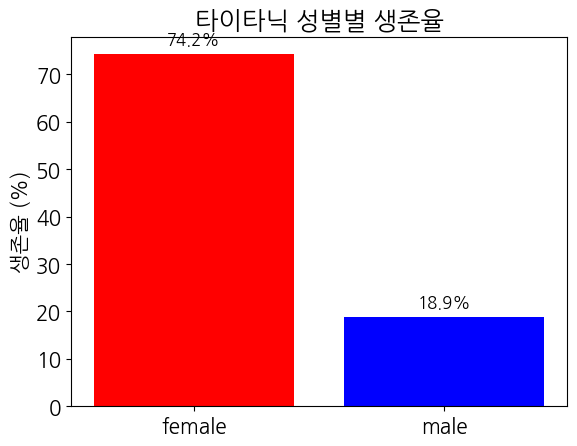

In [31]:
plt.bar(survived_by_sex.index, survived_by_sex* 100, color=['red', 'blue'])
plt.title('타이타닉 성별별 생존율')
plt.ylabel('생존율 (%)') 
for i, v in enumerate(survived_by_sex * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [74]:
survived_by_age = df.groupby('Age')['Survived'].mean()
survived_by_age

Age
0.42     1.0
0.67     1.0
0.75     1.0
0.83     1.0
0.92     1.0
        ... 
70.00    0.0
70.50    0.0
71.00    0.0
74.00    0.0
80.00    1.0
Name: Survived, Length: 89, dtype: float64

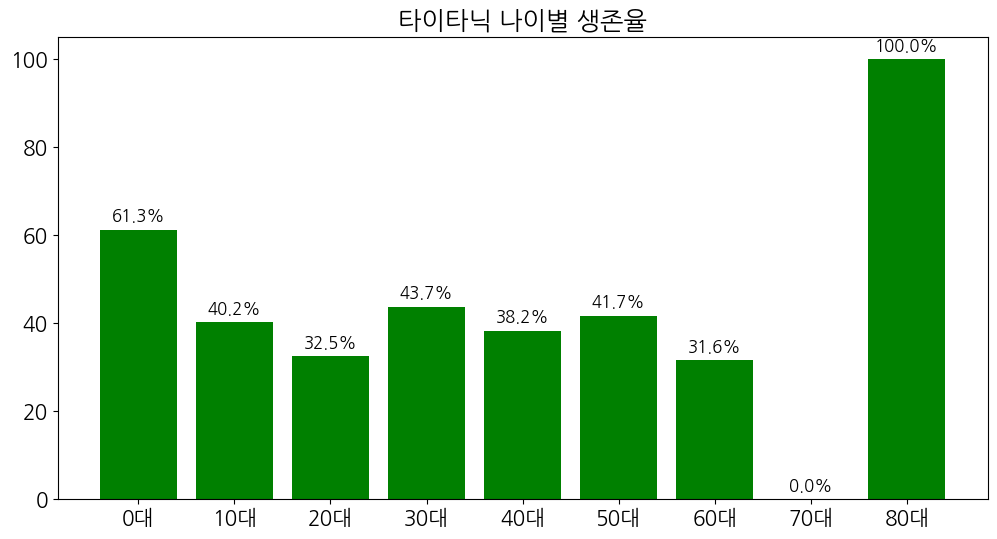

In [75]:
# 1) 나이를 10대 단위로 구간화
df['AgeBin'] = (df['Age'] // 10).astype(int) * 10

# 2) 생존율 계산
survived_by_age = df.groupby('AgeBin')['Survived'].mean()

# 3) 라벨을 "10대" 이런 식으로 변환
labels = [f"{age}대" for age in survived_by_age.index]

# 4) 그래프
plt.figure(figsize=(12,6))
plt.bar(labels, survived_by_age * 100, color='green')
plt.title('타이타닉 나이별 생존율')

# 5) 막대 위 숫자 표시
for i, v in enumerate(survived_by_age * 100):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=12)

In [41]:
survived_by_pclass = df.groupby('Pclass')['Survived'].mean()
survived_by_pclass

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

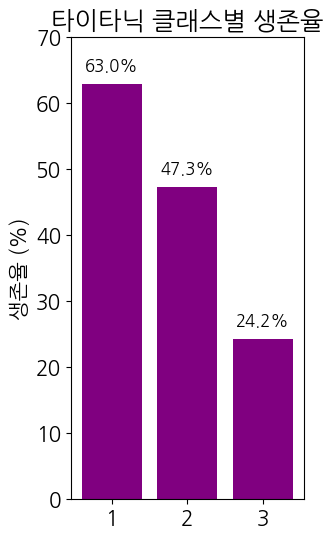

In [86]:
plt.figure(figsize=(3,6))
x = range(len(survived_by_pclass))
plt.bar(x, survived_by_pclass* 100, color='purple')
plt.title('타이타닉 클래스별 생존율')
plt.xticks(x, survived_by_pclass.index)
plt.ylabel('생존율 (%)') 
plt.ylim(0, 70)
for i, v in enumerate(survived_by_pclass * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [52]:
survived_by_sibsp = df.groupby('SibSp')['Survived'].mean()
survived_by_sibsp

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

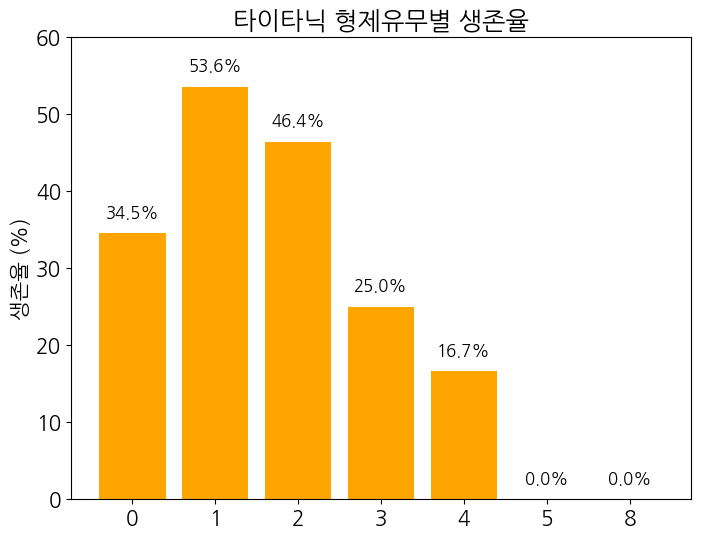

In [83]:
plt.figure(figsize=(8,6))
x = range(len(survived_by_sibsp))
plt.bar(x, survived_by_sibsp * 100, color='orange')
plt.xticks(x, survived_by_sibsp.index)
plt.title('타이타닉 형제유무별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 60)

for i, v in enumerate(survived_by_sibsp * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [58]:
survived_by_parch = df.groupby('Parch')['Survived'].mean()
survived_by_parch

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

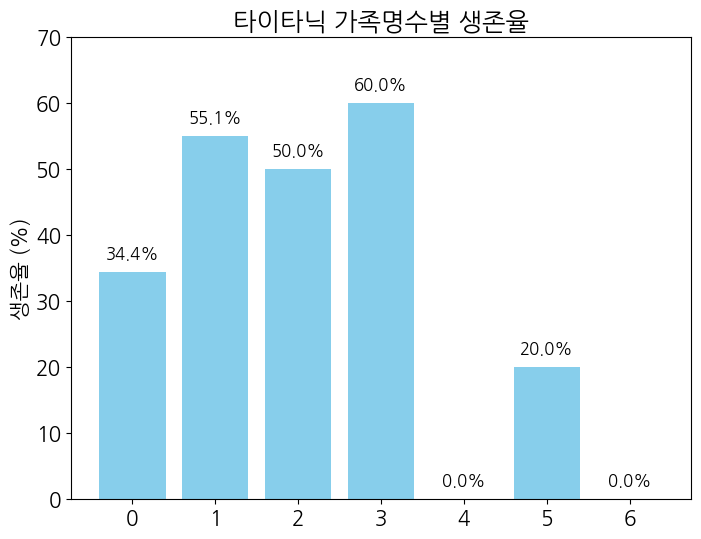

In [82]:
plt.figure(figsize=(8,6))
x = range(len(survived_by_parch))
plt.bar(x, survived_by_parch * 100, color='skyblue')
plt.xticks(x, survived_by_parch.index)
plt.title('타이타닉 가족명수별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 70)

for i, v in enumerate(survived_by_parch * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [60]:
survived_by_fare = df.groupby('Fare')['Survived'].mean()
survived_by_fare

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

In [61]:
survived_by_embarked = df.groupby('Embarked')['Survived'].mean()
survived_by_embarked

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

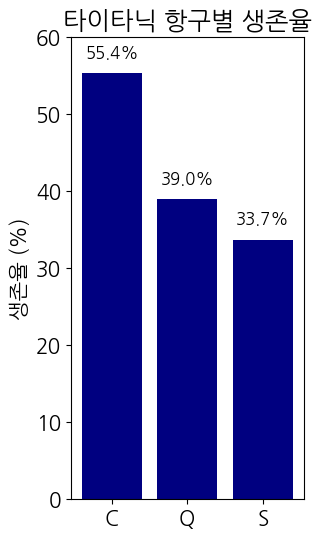

In [80]:
plt.figure(figsize=(3,6))
x = range(len(survived_by_embarked))
plt.bar(x, survived_by_embarked * 100, color='navy')
plt.xticks(x, survived_by_embarked.index)
plt.title('타이타닉 항구별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 60)

for i, v in enumerate(survived_by_embarked * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

NameError: name 'label' is not defined

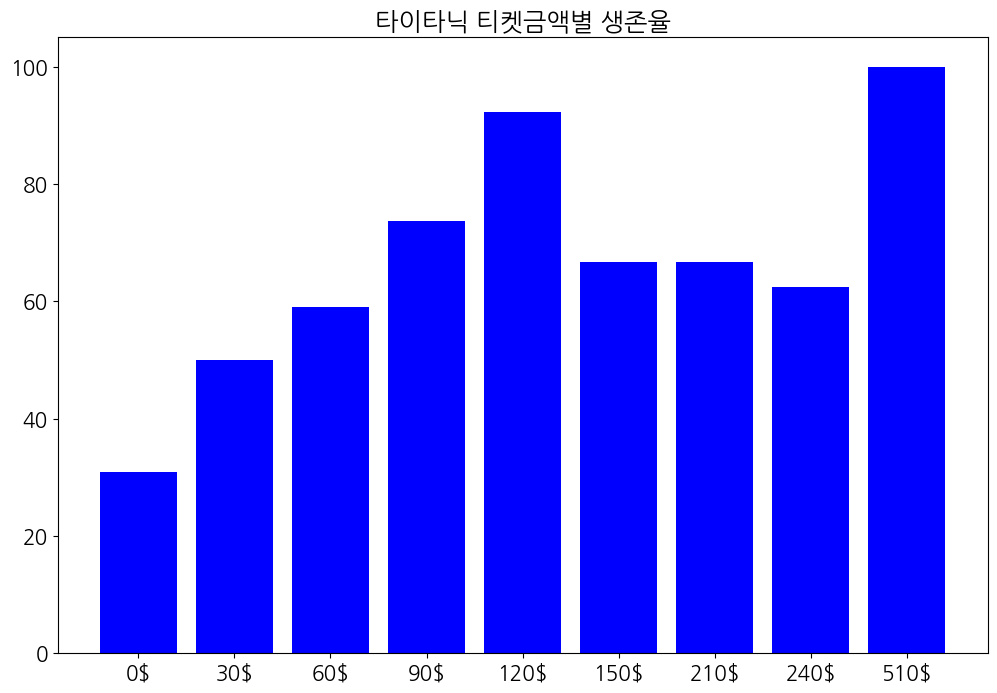

In [100]:
# 1) 나이를 10대 단위로 구간화
df['FareBin'] = (df['Fare'] // 30).astype(int) * 30

# 2) 생존율 계산
survived_by_fare = df.groupby('FareBin')['Survived'].mean()

# 3) 라벨을 "10대" 이런 식으로 변환
labels = [f"{fare}$" for fare in survived_by_fare.index]

# 4) 그래프
plt.figure(figsize=(12,8))
plt.bar(labels, survived_by_fare * 100, color='blue')
plt.title('타이타닉 티켓금액별 생존율')
plt.xticks(range(len(labels)), label, rotation=45)
# 5) 막대 위 숫자 표시
for i, v in enumerate(survived_by_fare * 100):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=12)